In [2]:
import arxiv
import json
import os
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
QUERY = "large language models"
MAX_RESULTS = 50
OUTPUT_FILE = Path("data/raw_candidates.json")
TEMP_FILE = Path("data/raw_candidates.tmp.json")

# arXiv asks clients to avoid excessive requests.
# A conservative delay is better than getting rate-limited.
REQUEST_DELAY = 5.0
PAGE_SIZE = 25               # smaller pages = more but slower requests
NUM_RETRIES = 5
# # Retry configuration
# MAX_RETRIES = 8
# INITIAL_BACKOFF = 5
# MAX_BACKOFF = 300

# ============================================================
# HELPERS
# ============================================================
def load_existing_papers():
    """
    Load previously saved papers so the script can resume
    after a crash/interruption.
    """
    if not OUTPUT_FILE.exists():
        return []
    try:
        with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
            data = json.load(f)
        if isinstance(data, list):
            print(f"Loaded {len(data)} existing papers.")
            return data
        print("Existing file is not a list. Starting fresh.")
        return []
    except (json.JSONDecodeError, OSError) as e:
        print(f"Could not read existing output: {e}")
        print("Starting with an empty dataset.")
        return []

def save_papers(papers):
    """
    Atomically save papers.
    We first write to a temporary file and then replace the
    real file. This prevents a crash during json.dump() from
    leaving the main JSON file half-written.
    """
    OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
    with open(TEMP_FILE, "w", encoding="utf-8") as f:
        json.dump(papers, f, indent=2, ensure_ascii=False)
        f.flush()
        os.fsync(f.fileno())
    # Atomic replacement
    os.replace(TEMP_FILE, OUTPUT_FILE)

def paper_to_dict(paper):
    """
    Convert an arxiv.Result object into a JSON-serializable dict.
    """
    return {
        "title": paper.title,
        "authors": [a.name for a in paper.authors],
        "abstract": paper.summary,
        "arxiv_id": paper.entry_id,
        "published": (paper.published.isoformat() if paper.published else None),
        "updated": (paper.updated.isoformat() if paper.updated else None),
        "categories": paper.categories,
        "primary_category": paper.primary_category,
        "pdf_url": paper.pdf_url,
        "doi": paper.doi,
        "journal": paper.journal_ref,
        "comments": paper.comment,
    }

# ============================================================
# MAIN
# ============================================================
def main():
    # --------------------------------------------------------
    # Load previous progress
    # --------------------------------------------------------
    papers = load_existing_papers()
    existing_ids = {paper["arxiv_id"] for paper in papers if "arxiv_id" in paper}
    print(f"Already have {len(existing_ids)} unique papers.")
    
    # --------------------------------------------------------
    # arXiv client
    # --------------------------------------------------------
    # client = arxiv.Client(
    #     page_size=20,
    #     delay_seconds=REQUEST_DELAY,
    #     num_retries=0,
    # )

    # client = arxiv.Client(
    #     page_size=10,
    #     delay_seconds=10,
    #     num_retries=5,
    # )

    client = arxiv.Client(
        page_size=PAGE_SIZE,
        delay_seconds=REQUEST_DELAY,
        num_retries=NUM_RETRIES,
    )

    '''
    in query field
    ti:   title
    au:   author
    abs:  abstract
    cat:  category
    all:  all searchable fields
    submittedDate: [YYYYMMDDHHMM TO YYYYMMDDHHMM]
    The API supports AND, OR, and ANDNOT
    if searched by the id_list field
    id_list=["1706.03762"]

    we can also sort things for eg by 
    sort_by=arxiv.SortCriterion.SubmittedDate,
    EG - 
        Relevance = "relevance"
        LastUpdatedDate = "lastUpdatedDate"
        SubmittedDate = "submittedDate"

    sort_order=arxiv.SortOrder.Descending,
    '''

    search = arxiv.Search(
        query=QUERY,
        max_results=MAX_RESULTS,
        sort_by=arxiv.SortCriterion.Relevance,
        sort_order=arxiv.SortOrder.Descending,
    )
    try:
        results = client.results(search)
        for paper in results:
            arxiv_id = paper.entry_id
            # ----------------------------------------------
            # Skip duplicates when resuming
            # ----------------------------------------------
            if arxiv_id in existing_ids:
                print(f"Skipping existing: {arxiv_id}")
                continue
            # ----------------------------------------------
            # Convert paper
            # ----------------------------------------------
            try:
                record = paper_to_dict(paper)
                papers.append(record)
                existing_ids.add(arxiv_id)
                # ------------------------------------------
                # SAVE IMMEDIATELY
                # ------------------------------------------
                save_papers(papers)
                print(f"[{len(papers)}/{MAX_RESULTS}] Saved: {paper.title[:100]}")
            except Exception as e:
                print(f"Failed to process {arxiv_id}: {e}")
                # Don't kill the entire job because one
                # paper has malformed/unexpected data.
                continue
    except KeyboardInterrupt:
        save_papers(papers)
        print("\nInterrupted by user.")
        print(f"Progress saved: {len(papers)} papers.")
        return
    except Exception as e:
        print(f"\nRequest failed: {type(e).__name__}: {e}")
        print("Attempting to preserve current progress...")
        save_papers(papers)
        print(f"Progress saved: {len(papers)} papers.")
        raise
    # --------------------------------------------------------
    # Final save
    # --------------------------------------------------------
    save_papers(papers)
    print(f"\nDone. Saved {len(papers)} unique papers to {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

Loaded 0 existing papers.
Already have 0 unique papers.

Request failed: HTTPError: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=large+language+models&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=25)
Attempting to preserve current progress...
Progress saved: 0 papers.


HTTPError: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=large+language+models&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=25)

In [5]:
import arxiv
import time
from datetime import datetime

# ============================================================
# CONFIG
# ============================================================
QUERY = "large language models"

# Keep this very small for a rate-limit test.
MAX_RESULTS = 3

# Wait between requests.
REQUEST_DELAY = 10.0

# Don't let the client itself retry silently.
NUM_RETRIES = 0


def test_arxiv_api():
    print("=" * 60)
    print("arXiv API RATE-LIMIT TEST")
    print("=" * 60)
    print(f"Time: {datetime.now().isoformat()}")
    print(f"Query: {QUERY}")
    print(f"Results requested: {MAX_RESULTS}")
    print(f"Delay: {REQUEST_DELAY}s")
    print()

    client = arxiv.Client(
        page_size=3,
        delay_seconds=REQUEST_DELAY,
        num_retries=NUM_RETRIES,
    )

    search = arxiv.Search(
        query=QUERY,
        max_results=MAX_RESULTS,
        sort_by=arxiv.SortCriterion.Relevance,
        sort_order=arxiv.SortOrder.Descending,
    )

    print("Sending request to arXiv...")
    start = time.time()

    try:
        results = client.results(search)

        count = 0

        for paper in results:
            count += 1
            print(f"\n[{count}] SUCCESS")
            print(f"Title: {paper.title}")
            print(f"arXiv ID: {paper.entry_id}")

        elapsed = time.time() - start

        print("\n" + "=" * 60)
        print("RESULT: REQUEST SUCCEEDED")
        print("=" * 60)
        print(f"Received {count} result(s)")
        print(f"Request time: {elapsed:.2f}s")
        print("You are NOT currently being rate-limited by this test.")

    except Exception as e:
        elapsed = time.time() - start

        print("\n" + "=" * 60)
        print("RESULT: REQUEST FAILED")
        print("=" * 60)
        print(f"Exception type: {type(e).__name__}")
        print(f"Error: {e}")
        print(f"Elapsed time: {elapsed:.2f}s")

        print("\nPossible causes:")
        print("- arXiv rate limiting")
        print("- Temporary API/server issue")
        print("- Network problem")
        print("- Invalid/blocked request")

        print("\nIMPORTANT:")
        print("NUM_RETRIES = 0, so this test does not hide")
        print("the failure behind automatic retries.")


if __name__ == "__main__":
    test_arxiv_api()

arXiv API RATE-LIMIT TEST
Time: 2026-09-15T11:49:21.911615
Query: large language models
Results requested: 3
Delay: 10.0s

Sending request to arXiv...

RESULT: REQUEST FAILED
Exception type: HTTPError
Error: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=large+language+models&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=3)
Elapsed time: 31.73s

Possible causes:
- arXiv rate limiting
- Temporary API/server issue
- Network problem
- Invalid/blocked request

IMPORTANT:
NUM_RETRIES = 0, so this test does not hide
the failure behind automatic retries.


In [4]:
import requests
from datetime import datetime

URL = "https://export.arxiv.org/api/query"

params = {
    "search_query": "all:large language models",
    "start": 0,
    "max_results": 1,
}

headers = {
    "User-Agent": "arxiv-rate-limit-test/1.0 (contact: your-email@example.com)"
}

print("Time:", datetime.now().isoformat())
print("Sending raw HTTP request...")

try:
    response = requests.get(
        URL,
        params=params,
        headers=headers,
        timeout=30,
    )

    print("\nStatus:", response.status_code)
    print("URL:", response.url)
    print("Server:", response.headers.get("Server"))
    print("Retry-After:", response.headers.get("Retry-After"))
    print("Content-Type:", response.headers.get("Content-Type"))

    print("\nResponse:")
    print(response.text[:1000])

except requests.RequestException as e:
    print("\nREQUEST ERROR:")
    print(type(e).__name__, e)


Time: 2026-09-15T11:43:59.517134
Sending raw HTTP request...

Status: 429
URL: https://export.arxiv.org/api/query?search_query=all%3Alarge+language+models&start=0&max_results=1
Server: Google Frontend
Retry-After: None
Content-Type: text/html

Response:
Rate exceeded.


In [6]:
import requests

EMAIL = "YOUR_REAL_EMAIL@example.com"

HEADERS = {
    "User-Agent": f"research-test/1.0 (mailto:{EMAIL})"
}


def test(name, method, url, **kwargs):
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    try:
        response = requests.request(
            method,
            url,
            headers=HEADERS,
            timeout=20,
            **kwargs,
        )

        print("Status:", response.status_code)
        print("Content-Type:", response.headers.get("Content-Type"))
        print("Content-Length:", response.headers.get("Content-Length"))
        print("Retry-After:", response.headers.get("Retry-After"))

        if response.status_code == 200:
            print(">>> SUCCESS")
            print(response.text[:300].replace("\n", " "))

        elif response.status_code == 429:
            print(">>> RATE LIMITED")
            print(response.text[:300])

        else:
            print(">>> FAILED")
            print(response.text[:300])

    except requests.RequestException as e:
        print(">>> REQUEST ERROR")
        print(type(e).__name__, e)


# ------------------------------------------------------------
# 1. Normal arXiv website
# ------------------------------------------------------------
test(
    "1. arXiv website",
    "GET",
    "https://arxiv.org/",
)


# ------------------------------------------------------------
# 2. Export website
# ------------------------------------------------------------
test(
    "2. export.arxiv.org",
    "GET",
    "https://export.arxiv.org/",
)


# ------------------------------------------------------------
# 3. arXiv API - minimal query
# ------------------------------------------------------------
test(
    "3. arXiv API - 1 result",
    "GET",
    "https://export.arxiv.org/api/query",
    params={
        "search_query": "all:large language models",
        "start": 0,
        "max_results": 1,
    },
)


# ------------------------------------------------------------
# 4. arXiv API using arxiv.org instead of export.arxiv.org
# ------------------------------------------------------------
test(
    "4. arXiv API - arxiv.org endpoint",
    "GET",
    "https://arxiv.org/api/query",
    params={
        "search_query": "all:large language models",
        "start": 0,
        "max_results": 1,
    },
)


# ------------------------------------------------------------
# 5. Direct paper page
# ------------------------------------------------------------
test(
    "5. Direct paper page",
    "GET",
    "https://arxiv.org/abs/1706.03762",
)


print("\n" + "=" * 60)
print("DIAGNOSTIC COMPLETE")
print("=" * 60)



1. arXiv website
Status: 200
Content-Type: text/html; charset=utf-8
Content-Length: 38051
Retry-After: None
>>> SUCCESS
<!DOCTYPE html> <html lang="en">  <head><script>document.documentElement.classList.add('js');</script>  <title>arXiv.org e-Print archive</title>   <meta name="viewport" content="width=device-width, initial-scale=1">   <link rel="apple-touch-icon" sizes="180x180" href="/static/browse/0.3.4/images/ico

2. export.arxiv.org
Status: 200
Content-Type: text/html; charset=utf-8
Content-Length: 7559
Retry-After: None
>>> SUCCESS
<!DOCTYPE html> <html lang="en">  <head><script>document.documentElement.classList.add('js');</script>  <title>arXiv.org e-Print archive</title>   <meta name="viewport" content="width=device-width, initial-scale=1">   <link rel="apple-touch-icon" sizes="180x180" href="/static/browse/0.3.4/images/ico

3. arXiv API - 1 result
Status: 429
Content-Type: text/html
Content-Length: 14
Retry-After: None
>>> RATE LIMITED
Rate exceeded.

4. arXiv API - arxiv.or

In [9]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote

EMAIL = "YOUR_REAL_EMAIL@example.com"

headers = {
    "User-Agent": f"research-test/1.0 (mailto:{EMAIL})"
}

query = "large language models"

url = (
    "https://arxiv.org/search/"
    "?query=" + quote(query)
    + "&searchtype=all"
    "&abstracts=show"
    "&order=-announced_date_first"
    "&size=10"
)

print("Requesting:")
print(url)

response = requests.get(
    url,
    headers=headers,
    timeout=30,
)

print("\nStatus:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))

if response.status_code != 200:
    print(response.text[:500])
    raise SystemExit

soup = BeautifulSoup(response.text, "html.parser")

results = soup.select("li.arxiv-result")

print(f"\nFound {len(results)} results\n")

for i, result in enumerate(results, 1):

    title = result.select_one("p.title")
    title = title.get_text(" ", strip=True) if title else "N/A"

    link = result.select_one("p.list-title a")
    link = link.get("href") if link else "N/A"

    authors = result.select("p.authors a")
    authors = [a.get_text(" ", strip=True) for a in authors]

    abstract = result.select_one("span.abstract-full")
    abstract = abstract.get_text(" ", strip=True) if abstract else "N/A"

    print("=" * 60)
    print(f"#{i}")
    print("Title:", title)
    print("URL:", link)
    print("Authors:", ", ".join(authors))
    print("Abstract:", abstract[:300], "...")


Requesting:
https://arxiv.org/search/?query=large%20language%20models&searchtype=all&abstracts=show&order=-announced_date_first&size=10

Status: 400
Content-Type: text/html; charset=utf-8
<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="utf-8"/>
<meta name="viewport" content="width=device-width, initial-scale=1"/>
<!-- new favicon config and versions by realfavicongenerator.net -->
<link rel="apple-touch-icon" sizes="180x180" href="https://static.arxiv.org/static/base/1.0.0a5/images/icons/apple-touch-icon.png">
<link rel="icon" type="image/png" sizes="32x32" href="https://static.arxiv.org/static/base/1.0.0a5/images/icons/favicon-32x32.png">
<link rel="icon" type="imag


SystemExit: 

/Users/nataltiger/Documents/Plaksha Course/Python Programming/Capstone_Project/ArXiv_Paper_Suggester/.arxiv_paper_suggester/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3831: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [1]:
import json
import statistics

lengths = []

with open("/Users/nataltiger/Documents/Plaksha Course/Python Programming/Capstone_Project/ArXiv_Paper_Suggester/data/corpus_v1.jsonl", encoding="utf-8") as f:
    for line in f:
        paper = json.loads(line)
        abstract = paper.get("abstract") or ""
        if abstract:
            lengths.append(len(abstract))

print("Papers:", len(lengths))
print("Min:", min(lengths))
print("Max:", max(lengths))
print("Mean:", statistics.mean(lengths))
print("Median:", statistics.median(lengths))


Papers: 188
Min: 237
Max: 3202
Mean: 1243.718085106383
Median: 1181.0


(array([ 4.,  4.,  8., 10., 25., 35., 24., 20., 19., 15.,  9.,  7.,  0.,
         2.,  2.,  2.,  1.,  0.,  0.,  1.]),
 array([ 237.  ,  385.25,  533.5 ,  681.75,  830.  ,  978.25, 1126.5 ,
        1274.75, 1423.  , 1571.25, 1719.5 , 1867.75, 2016.  , 2164.25,
        2312.5 , 2460.75, 2609.  , 2757.25, 2905.5 , 3053.75, 3202.  ]),
 <BarContainer object of 20 artists>)

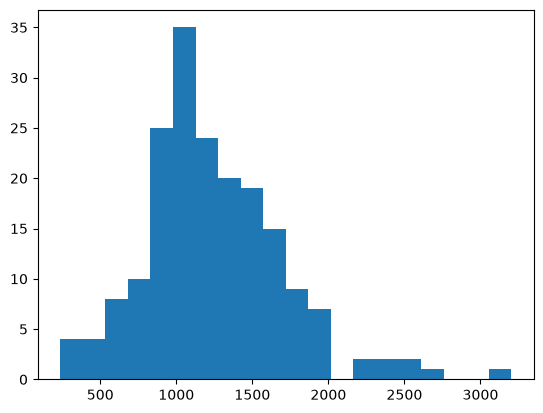

In [3]:
import matplotlib.pyplot as plt 
plt.hist(lengths, bins=20)

In [ ]:
import arxiv
import json
import os
import time
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
QUERY = "large language models"
MAX_RESULTS = 50
OUTPUT_FILE = Path("data/raw_candidates.json")
TEMP_FILE = Path("data/raw_candidates.tmp.json")

# Very conservative settings (matching what worked in the attached collectors)
REQUEST_DELAY = 5.0          # seconds between requests
PAGE_SIZE = 25               # smaller pages = more but slower requests
NUM_RETRIES = 5

# ============================================================
# HELPERS
# ============================================================
def load_existing_papers():
    if not OUTPUT_FILE.exists():
        return []
    try:
        with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
            data = json.load(f)
        if isinstance(data, list):
            print(f"Loaded {len(data)} existing papers.")
            return data
        print("Existing file is not a list. Starting fresh.")
        return []
    except (json.JSONDecodeError, OSError) as e:
        print(f"Could not read existing output: {e}")
        return []

def save_papers(papers):
    OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
    with open(TEMP_FILE, "w", encoding="utf-8") as f:
        json.dump(papers, f, indent=2, ensure_ascii=False)
        f.flush()
        os.fsync(f.fileno())
    os.replace(TEMP_FILE, OUTPUT_FILE)

def paper_to_dict(paper):
    return {
        "title": paper.title,
        "authors": [a.name for a in paper.authors],
        "abstract": paper.summary,
        "arxiv_id": paper.entry_id,
        "published": (paper.published.isoformat() if paper.published else None),
        "updated": (paper.updated.isoformat() if paper.updated else None),
        "categories": list(paper.categories),
        "primary_category": paper.primary_category,
        "pdf_url": paper.pdf_url,
        "doi": paper.doi,
        "journal": paper.journal_ref,
        "comments": paper.comment,
    }

# ============================================================
# MAIN
# ============================================================
def main():
    papers = load_existing_papers()
    existing_ids = {p["arxiv_id"] for p in papers if "arxiv_id" in p}
    print(f"Already have {len(existing_ids)} unique papers.")

    client = arxiv.Client(
        page_size=PAGE_SIZE,
        delay_seconds=REQUEST_DELAY,
        num_retries=NUM_RETRIES,
    )

    search = arxiv.Search(
        query=QUERY,
        max_results=MAX_RESULTS,
        sort_by=arxiv.SortCriterion.Relevance,
        sort_order=arxiv.SortOrder.Descending,
    )

    try:
        results = client.results(search)

        for paper in results:
            arxiv_id = paper.entry_id

            if arxiv_id in existing_ids:
                print(f"Skipping existing: {arxiv_id}")
                continue

            try:
                record = paper_to_dict(paper)
                papers.append(record)
                existing_ids.add(arxiv_id)
                save_papers(papers)
                print(f"[{len(papers)}/{MAX_RESULTS}] Saved: {paper.title[:100]}")
            except Exception as e:
                print(f"Failed to process {arxiv_id}: {e}")
                continue

    except KeyboardInterrupt:
        print("\nInterrupted by user.")
        save_papers(papers)
        print(f"Progress saved: {len(papers)} papers.")
        return
    except Exception as e:
        print(f"\nRequest failed: {type(e).__name__}: {e}")
        save_papers(papers)
        print(f"Progress saved: {len(papers)} papers.")
        raise

    save_papers(papers)
    print(f"\nDone. Saved {len(papers)} unique papers to {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

In [1]:

import arxiv
import json
import os
import random
import time
from pathlib import Path


# ============================================================
# CONFIG
# ============================================================

QUERY = "large language models"

MAX_RESULTS = 50

OUTPUT_FILE = Path("data/raw_candidates.json")
TEMP_FILE = Path("data/raw_candidates.tmp.json")

# arXiv API request configuration
PAGE_SIZE = 10
REQUEST_DELAY = 10

# Retry configuration
MAX_RETRIES = 8
INITIAL_BACKOFF = 30
MAX_BACKOFF = 600


# ============================================================
# HELPERS
# ============================================================

def load_existing_papers():
    """
    Load previously saved papers so the script can resume
    after a crash or interruption.
    """

    if not OUTPUT_FILE.exists():
        return []

    try:
        with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, list):
            print(f"Loaded {len(data)} existing papers.")
            return data

        print("Existing file is not a list. Starting fresh.")
        return []

    except (json.JSONDecodeError, OSError) as e:
        print(f"Could not read existing output: {e}")
        print("Starting with an empty dataset.")
        return []


def save_papers(papers):
    """
    Atomically save papers.

    Data is first written to a temporary file and then
    atomically moved into place.

    This prevents the main JSON file from being left
    half-written if the program crashes during saving.
    """

    OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

    with open(TEMP_FILE, "w", encoding="utf-8") as f:

        json.dump(
            papers,
            f,
            indent=2,
            ensure_ascii=False,
        )

        f.flush()
        os.fsync(f.fileno())

    os.replace(TEMP_FILE, OUTPUT_FILE)


def paper_to_dict(paper):
    """
    Convert an arxiv.Result object into a JSON-serializable dict.
    """

    return {
        "title": paper.title,
        "authors": [a.name for a in paper.authors],
        "abstract": paper.summary,
        "arxiv_id": paper.entry_id,

        "published": (
            paper.published.isoformat()
            if paper.published
            else None
        ),

        "updated": (
            paper.updated.isoformat()
            if paper.updated
            else None
        ),

        "categories": paper.categories,
        "primary_category": paper.primary_category,
        "pdf_url": paper.pdf_url,
        "doi": paper.doi,
        "journal": paper.journal_ref,
        "comments": paper.comment,
    }


def calculate_backoff(attempt):
    """
    Exponential backoff with jitter.

    Example:

        attempt 0 -> ~30 sec
        attempt 1 -> ~60 sec
        attempt 2 -> ~120 sec
        attempt 3 -> ~240 sec
        attempt 4 -> ~480 sec
        attempt 5 -> ~600 sec max

    Jitter prevents repeated retries from happening
    at exactly the same time.
    """

    delay = min(
        MAX_BACKOFF,
        INITIAL_BACKOFF * (2 ** attempt),
    )

    delay += random.uniform(0, 5)

    return delay


# ============================================================
# MAIN
# ============================================================

def main():

    # --------------------------------------------------------
    # Load previous progress
    # --------------------------------------------------------

    papers = load_existing_papers()

    existing_ids = {
        paper["arxiv_id"]
        for paper in papers
        if "arxiv_id" in paper
    }

    print(
        f"Already have {len(existing_ids)} unique papers."
    )

    # --------------------------------------------------------
    # arXiv client
    # --------------------------------------------------------

    client = arxiv.Client(
        page_size=PAGE_SIZE,
        delay_seconds=REQUEST_DELAY,

        # We handle retries ourselves.
        num_retries=0,
    )

    # --------------------------------------------------------
    # Search
    # --------------------------------------------------------

    search = arxiv.Search(
        query=QUERY,
        max_results=MAX_RESULTS,

        sort_by=arxiv.SortCriterion.Relevance,
        sort_order=arxiv.SortOrder.Descending,
    )

    # --------------------------------------------------------
    # Collect
    # --------------------------------------------------------

    collected_this_run = 0

    for attempt in range(MAX_RETRIES):

        try:

            print(
                f"\nStarting arXiv request "
                f"(attempt {attempt + 1}/{MAX_RETRIES})..."
            )

            results = client.results(search)

            for paper in results:

                arxiv_id = paper.entry_id

                # ------------------------------------------------
                # Skip papers we already collected
                # ------------------------------------------------

                if arxiv_id in existing_ids:

                    print(
                        f"Skipping existing: {arxiv_id}"
                    )

                    continue

                # ------------------------------------------------
                # Convert paper
                # ------------------------------------------------

                try:

                    record = paper_to_dict(paper)

                    papers.append(record)
                    existing_ids.add(arxiv_id)

                    collected_this_run += 1

                    # ------------------------------------------------
                    # Save immediately
                    # ------------------------------------------------

                    save_papers(papers)

                    print(
                        f"[{collected_this_run}/{MAX_RESULTS}] "
                        f"Saved: {paper.title[:100]}"
                    )

                    # ------------------------------------------------
                    # Stop after collecting the requested number
                    # of NEW papers.
                    # ------------------------------------------------

                    if collected_this_run >= MAX_RESULTS:

                        print(
                            "\nReached MAX_RESULTS."
                        )

                        save_papers(papers)

                        print(
                            f"Total papers in dataset: "
                            f"{len(papers)}"
                        )

                        return

                except Exception as e:

                    print(
                        f"Failed to process "
                        f"{arxiv_id}: {e}"
                    )

                    # Continue with the next paper.
                    continue

            # ----------------------------------------------------
            # If we got here, the iteration completed successfully.
            # ----------------------------------------------------

            print(
                "\nCollection completed successfully."
            )

            save_papers(papers)

            print(
                f"Total papers in dataset: "
                f"{len(papers)}"
            )

            return

        except KeyboardInterrupt:

            print(
                "\nInterrupted by user."
            )

            save_papers(papers)

            print(
                f"Progress preserved: "
                f"{len(papers)} papers."
            )

            return

        except Exception as e:

            error_message = str(e)

            # ----------------------------------------------------
            # Check whether this looks like a rate limit.
            # ----------------------------------------------------

            is_rate_limit = (
                "429" in error_message
                or "Too Many Requests" in error_message
            )

            if not is_rate_limit:

                print(
                    f"\nNon-rate-limit error:"
                    f" {type(e).__name__}: {e}"
                )

                save_papers(papers)

                print(
                    f"Progress preserved: "
                    f"{len(papers)} papers."
                )

                raise

            # ----------------------------------------------------
            # Rate limited
            # ----------------------------------------------------

            if attempt == MAX_RETRIES - 1:

                print(
                    "\nMaximum retry attempts reached."
                )

                save_papers(papers)

                print(
                    f"Progress preserved: "
                    f"{len(papers)} papers."
                )

                raise

            backoff = calculate_backoff(attempt)

            print(
                "\nArXiv rate limit detected (HTTP 429)."
            )

            print(
                f"Waiting {backoff:.1f} seconds "
                f"before retrying..."
            )

            # Save before sleeping.
            save_papers(papers)

            time.sleep(backoff)

    # --------------------------------------------------------
    # Final save
    # --------------------------------------------------------

    save_papers(papers)

    print(
        f"\nDone. "
        f"Saved {len(papers)} unique papers "
        f"to {OUTPUT_FILE}"
    )


# if __name__ == "__main__":
#     main()
main()

Loaded 0 existing papers.
Already have 0 unique papers.

Starting arXiv request (attempt 1/8)...

ArXiv rate limit detected (HTTP 429).
Waiting 30.4 seconds before retrying...

Starting arXiv request (attempt 2/8)...

ArXiv rate limit detected (HTTP 429).
Waiting 60.4 seconds before retrying...

Starting arXiv request (attempt 3/8)...

ArXiv rate limit detected (HTTP 429).
Waiting 122.5 seconds before retrying...


KeyboardInterrupt: 